In [1]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
def linear(t, a, b):
    return a + b * t

def normal(t, m, s, N = 1):
    return N/np.sqrt(2*np.pi) * 1/s * np.exp(-0.5*((t-m)/s)**2)


In [4]:
dataNa  = pd.read_csv('acqna.csv')
dataNa.keys()
ech0 = dataNa[" energy"][dataNa[" ch"] == 0]
ech1 = dataNa[" energy"][dataNa[" ch"] == 1]


Index(['n', ' ch', ' t', ' qlong', ' energy'], dtype='object')

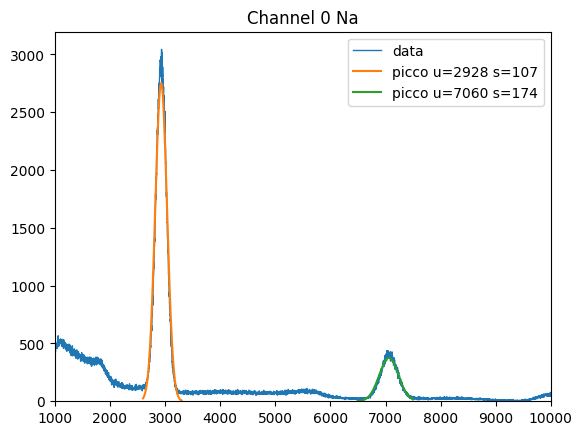

In [29]:
fig, ax = plt.subplots()
counts, bins = np.histogram(ech0, bins=50000)

wbins = bins[1] - bins[0]

plt.stairs(counts, bins, label='data')

xmin = 2600
xmax = 3300

x = dataNa[" energy"][dataNa[" ch"] == 0][dataNa[" energy"][dataNa[" ch"] == 0] < xmax][dataNa[" energy"][dataNa[" ch"] == 0][dataNa[" energy"][dataNa[" ch"] == 0] < xmax] > xmin]
count = len(x)*wbins

plt.plot(np.arange(xmin, xmax), normal(np.arange(xmin, xmax), np.mean(x), np.std(x, ddof = 1), count), label = 'picco u='+str(round(np.mean(x)))+' s='+str(round(np.std(x, ddof = 1))))

xmin = 6500
xmax = 7500

x = dataNa[" energy"][dataNa[" ch"] == 0][dataNa[" energy"][dataNa[" ch"] == 0] < xmax][dataNa[" energy"][dataNa[" ch"] == 0][dataNa[" energy"][dataNa[" ch"] == 0] < xmax] > xmin]
count = len(x)*wbins

plt.plot(np.arange(xmin, xmax), normal(np.arange(xmin, xmax), np.mean(x), np.std(x, ddof = 1), count), label = 'picco u='+str(round(np.mean(x)))+' s='+str(round(np.std(x, ddof = 1))))

ax.legend()

ax.set_title("Channel 0 Na")

ax.set_xlim(0,10000)

plt.show()

C:\Users\metru\AppData\Local\Temp\ipykernel_8144\433555514.py:5: OptimizeWarning: Covariance of the parameters could not be estimated
  p, sp = curve_fit(linear, ekeV, emis, sigma=semis)


[165.98201528   5.40903715] [inf inf]
[17.61992682 42.50214067]
[0.6627224  1.02420735]


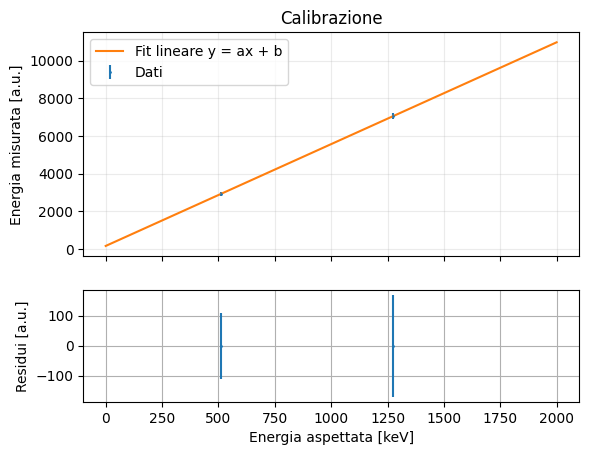

In [32]:
ekeV = np.array([511, 1274.537])
emis = np.array([2930, 7060])
semis = np.array([110, 170])

p, sp = curve_fit(linear, ekeV, emis, sigma=semis)

residui = emis - linear(ekeV, *p)


fig, ax = plt.subplots(2,1, sharex = True, height_ratios = [1,0.5])
ax[0].errorbar(ekeV, emis, yerr = semis, fmt='o', ms = 1, label = 'Dati')

ax[0].plot(np.arange(0, 2000), linear(np.arange(0, 2000), *p), label = "Fit lineare y = ax + b")

ax[1].set_xlabel("Energia aspettata [keV]")
ax[0].set_ylabel("Energia misurata [a.u.]")
ax[1].set_ylabel("Residui [a.u.]")

ax[0].legend()

ax[0].grid(alpha = 0.25)

ax[0].set_title("Calibrazione ch0")

ax[1].errorbar(ekeV, residui, yerr = semis, fmt='o', ms = 1)

ax[1].grid()


print(p, np.sqrt(np.diag(sp)))

print((emis-p[1])/p[0])
print(semis/p[0])


plt.show()

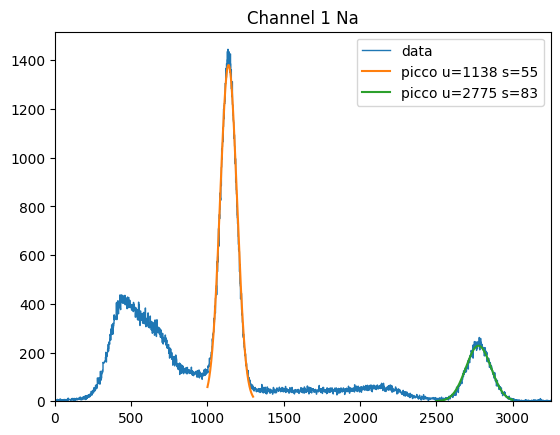

In [37]:
fig, ax = plt.subplots()
counts, bins = np.histogram(ech1, bins=50000)

wbins = bins[1] - bins[0]

plt.stairs(counts, bins, label='data')

xmin = 1000
xmax = 1300

x = dataNa[" energy"][dataNa[" ch"] == 1][dataNa[" energy"][dataNa[" ch"] == 1] < xmax][dataNa[" energy"][dataNa[" ch"] == 1][dataNa[" energy"][dataNa[" ch"] == 1] < xmax] > xmin]
count = len(x)*wbins

plt.plot(np.arange(xmin, xmax), normal(np.arange(xmin, xmax), np.mean(x), np.std(x, ddof = 1), count), label = 'picco u='+str(round(np.mean(x)))+' s='+str(round(np.std(x, ddof = 1))))

xmin = 2500
xmax = 3000

x = dataNa[" energy"][dataNa[" ch"] == 1][dataNa[" energy"][dataNa[" ch"] == 1] < xmax][dataNa[" energy"][dataNa[" ch"] == 1][dataNa[" energy"][dataNa[" ch"] == 1] < xmax] > xmin]
count = len(x)*wbins

plt.plot(np.arange(xmin, xmax), normal(np.arange(xmin, xmax), np.mean(x), np.std(x, ddof = 1), count), label = 'picco u='+str(round(np.mean(x)))+' s='+str(round(np.std(x, ddof = 1))))

ax.legend()

ax.set_title("Channel 1 Na")

ax.set_xlim(0,3250)

plt.show()

C:\Users\metru\AppData\Local\Temp\ipykernel_8144\2728042358.py:5: OptimizeWarning: Covariance of the parameters could not be estimated
  p, sp = curve_fit(linear, ekeV, emis, sigma=semis)


[42.4238511   2.14789853] [inf inf]
[26.82104693 65.47854637]
[1.41429876 1.88573168]


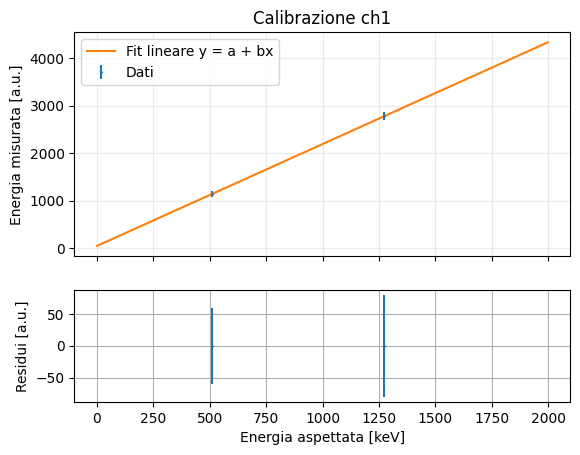

In [40]:
ekeV = np.array([511, 1274.537])
emis = np.array([1140, 2780])
semis = np.array([60, 80])

p, sp = curve_fit(linear, ekeV, emis, sigma=semis)

residui = emis - linear(ekeV, *p)


fig, ax = plt.subplots(2,1, sharex = True, height_ratios = [1,0.5])
ax[0].errorbar(ekeV, emis, yerr = semis, fmt='o', ms = 1, label = 'Dati')

ax[0].plot(np.arange(0, 2000), linear(np.arange(0, 2000), *p), label = "Fit lineare y = a + bx")

ax[1].set_xlabel("Energia aspettata [keV]")
ax[0].set_ylabel("Energia misurata [a.u.]")
ax[1].set_ylabel("Residui [a.u.]")

ax[0].legend()

ax[0].grid(alpha = 0.25)

ax[0].set_title("Calibrazione ch1")

ax[1].errorbar(ekeV, residui, yerr = semis, fmt='o', ms = 1)

ax[1].grid()


print(p, np.sqrt(np.diag(sp)))

print((emis-p[1])/p[0])
print(semis/p[0])


plt.show()

In [ ]:
dataCo  = pd.read_csv('acqco.csv')
dataNa.keys()
ech0 = dataNa[" energy"][dataNa[" ch"] == 0]
ech1 = dataNa[" energy"][dataNa[" ch"] == 1]
